# pySpark: Spark на Python

<details>
    <summary>Задание X5Tech</summary>
    
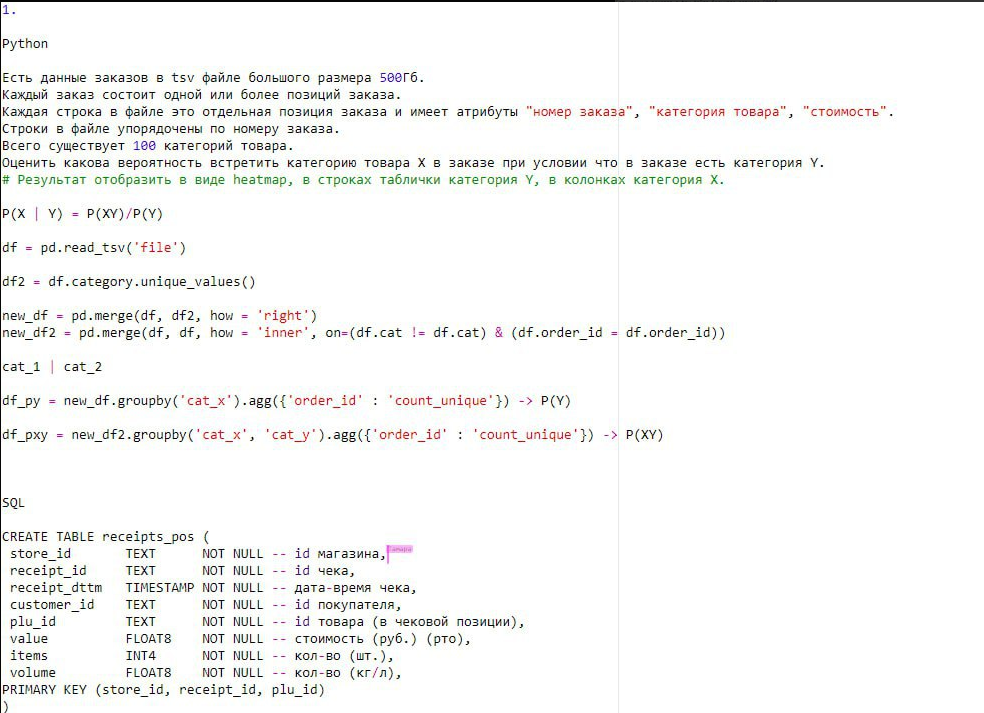
    
</details>   


<details> 
    <summary>Установка pyspark:</summary>
    
* Установить JDK (Java) Желательно ставить 11 версию (для лучшей совместимости со spark);
* Поставить JRE 1.8;
* Создать переменную в винде `%JAVA_HOME%` и указать путь до папки с JRE.
    Так же добавить `%JAVA_HOME%` в переменную Path: `%JAVA_HOME%\bin`
* Spark ставить не нужно, так как Spark приложение запускается через pyspark!

</details>  

<!-- C:\Users\ilyao\anaconda3\python.exe -m  -->

https://stepik.org/course/210272/syllabus

In [1]:
import random
import os
from tqdm.notebook import tqdm

import pandas as pd
import numpy as np

# Визуализация
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\ilyao\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Генерация данных

In [2]:
# Количество категорий и заказов
num_categories = 100
num_orders = 100000

# Генерация случайных данных
categories = [f"cat_{i}" for i in range(1, num_categories + 1)]
data = [(random.randint(1, num_orders), random.choice(categories), random.random() * 100) for _ in range(num_orders * 5)]

## Решение Pandas

In [3]:
df = pd.DataFrame(data, columns=["order_id", "category", "price"])

In [39]:
df.info(verbose=False)
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Columns: 3 entries, order_id to price
dtypes: float64(1), int64(1), object(1)
memory usage: 11.4+ MB


,order_id,category,price
0,9137,cat_1,80.959564
1,91952,cat_66,20.564479
2,8606,cat_91,90.293592


### вар1

In [5]:
lst_category = df.category.unique()

In [6]:
df_result = pd.DataFrame()

for cat in tqdm(lst_category):
    
    temp_filter = df.loc[df.category == cat].drop_duplicates(['order_id', 'category'])

    temp_unique_orders = temp_filter.order_id.nunique()

    temp_categoryes = (
        df
        .merge(temp_filter, how='inner', on='order_id')
        .groupby(by='category_x', as_index=False).agg({'order_id':'nunique'})
        .assign(
            main_cat = cat
            , total_orders = temp_unique_orders
            , cat_x_probability = lambda _df: _df.order_id.div(_df.total_orders)
        )
    )

    df_result = pd.concat([df_result,temp_categoryes])


  0%|          | 0/100 [00:00<?, ?it/s]

In [7]:
df_result.query("main_cat=='cat_81'")

,category_x,order_id,main_cat,total_orders,cat_x_probability
0,cat_1,226,cat_81,4803,0.047054
1,cat_10,213,cat_81,4803,0.044347
2,cat_100,225,cat_81,4803,0.046846
3,cat_11,238,cat_81,4803,0.049552
4,cat_12,232,cat_81,4803,0.048303
...,...,...,...,...,...
95,cat_95,231,cat_81,4803,0.048095
96,cat_96,264,cat_81,4803,0.054966
97,cat_97,212,cat_81,4803,0.044139
98,cat_98,242,cat_81,4803,0.050385


In [8]:
df_pivot = df_result.pivot(index='main_cat', columns='category_x', values='cat_x_probability')

In [9]:
df_pivot

category_x,cat_1,cat_10,cat_100,cat_11,cat_12,cat_13,cat_14,cat_15,cat_16,cat_17,...,cat_90,cat_91,cat_92,cat_93,cat_94,cat_95,cat_96,cat_97,cat_98,cat_99
main_cat,,,,,,,,,,,,,,,,,,,,,
cat_1,1.000000,0.046239,0.053432,0.046856,0.050144,0.047883,0.047267,0.051171,0.054460,0.049733,...,0.049527,0.045828,0.050144,0.051171,0.050760,0.044801,0.039868,0.044390,0.047267,0.050349
cat_10,0.047219,1.000000,0.047639,0.044911,0.045960,0.048269,0.047849,0.050367,0.048898,0.050367,...,0.051207,0.044281,0.054774,0.056453,0.048269,0.043861,0.045121,0.048898,0.049318,0.049738
cat_100,0.052115,0.045500,1.000000,0.049709,0.049108,0.047905,0.050712,0.045701,0.049709,0.050912,...,0.050912,0.047905,0.048707,0.048707,0.047104,0.050110,0.045099,0.053117,0.051112,0.046101
cat_11,0.046445,0.043593,0.050519,1.000000,0.049501,0.050519,0.052964,0.047871,0.053168,0.050112,...,0.047668,0.049094,0.049297,0.050112,0.053371,0.054390,0.052353,0.045223,0.049094,0.049908
cat_12,0.049233,0.044189,0.049435,0.049031,1.000000,0.051251,0.049637,0.047014,0.047619,0.054479,...,0.049435,0.046610,0.046610,0.049233,0.049233,0.055287,0.050847,0.050847,0.041364,0.048628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cat_95,0.043854,0.042044,0.050292,0.053712,0.055120,0.048280,0.047878,0.051096,0.053309,0.047475,...,0.050493,0.048280,0.040233,0.046470,0.049286,1.000000,0.047677,0.050292,0.051700,0.052505
cat_96,0.040400,0.044773,0.046855,0.053519,0.052478,0.050396,0.048313,0.043315,0.044981,0.050604,...,0.050812,0.045398,0.046647,0.052270,0.050396,0.049354,1.000000,0.044565,0.048938,0.046855
cat_97,0.044226,0.047707,0.054259,0.045455,0.051597,0.048116,0.050573,0.048731,0.046069,0.049959,...,0.046478,0.050573,0.048321,0.046274,0.047297,0.051188,0.043817,1.000000,0.048526,0.047912


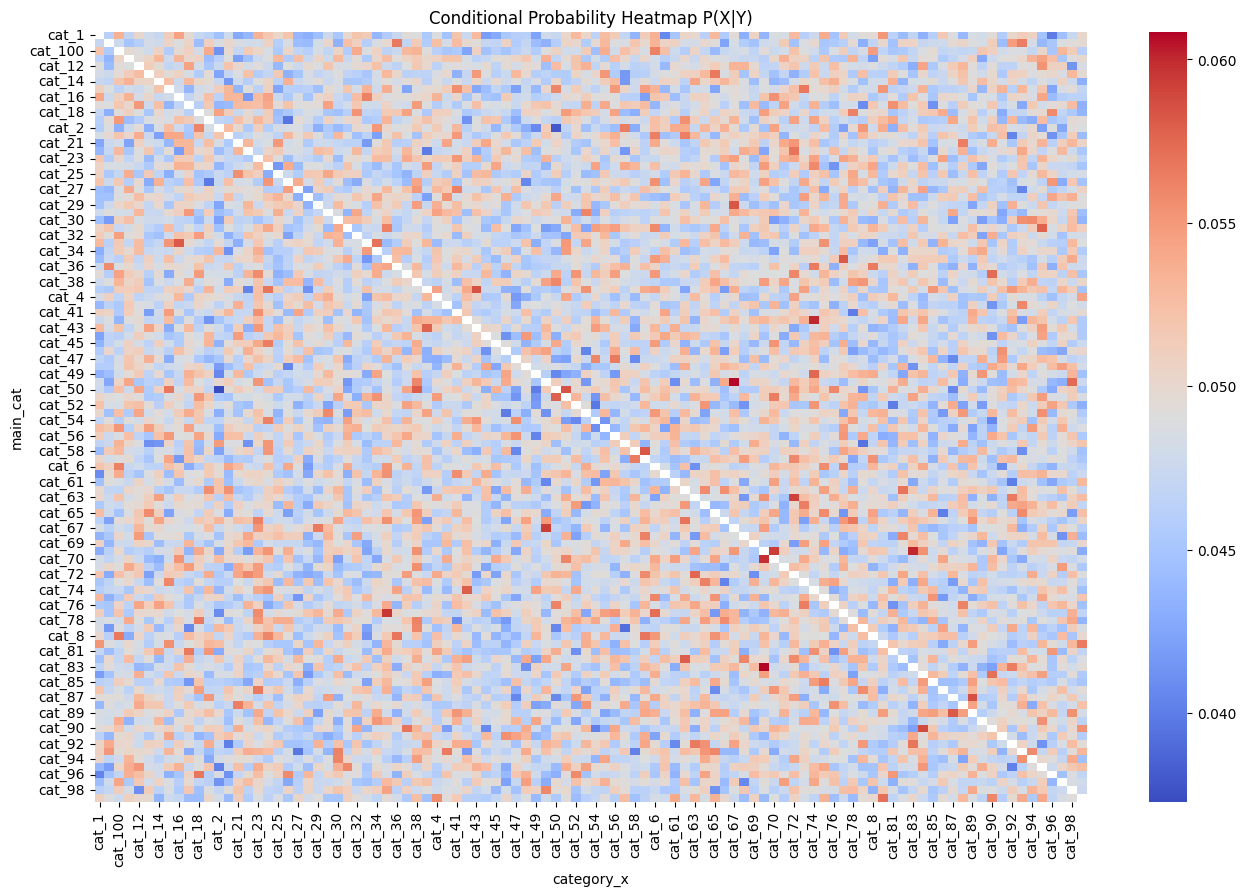

In [10]:
plt.figure(figsize=(16, 10))

sns.heatmap(df_pivot[df_pivot<1], annot=False, cmap="coolwarm")

plt.title("Conditional Probability Heatmap P(X|Y)")

plt.show()

### вар2 (ресурсоемкий)

In [58]:
(df
 .assign(total_orders = df.groupby('category').order_id.transform('nunique'))
 .merge(df, how='inner', on='order_id')
 .query(" category_x == 'cat_81' ")
 .groupby(['category_x','category_y'], as_index=False)
     .agg({'total_orders':'mean','order_id':'nunique'})
)

,category_x,category_y,total_orders,order_id
0,cat_81,cat_1,4803.0,226
1,cat_81,cat_10,4803.0,213
2,cat_81,cat_100,4803.0,225
3,cat_81,cat_11,4803.0,238
4,cat_81,cat_12,4803.0,232
...,...,...,...,...
95,cat_81,cat_95,4803.0,231
96,cat_81,cat_96,4803.0,264
97,cat_81,cat_97,4803.0,212
98,cat_81,cat_98,4803.0,242


### вар3

## решение spark

In [5]:
from pyspark.sql import SparkSession
# from pyspark.sql.functions import col, countDistinct, rand
# import pyspark.sql.functions as F

In [6]:
# Инициализация сессии Spark
spark = SparkSession.builder \
        .appName("CategoryProbability") \
        .master("local[4]") \
        .config('spark.driver.memory', '2g') \
        .getOrCreate()

In [7]:
spark

In [12]:
# sdf = spark.createDataFrame(data, ["order_id", "category", "price"])

In [8]:
spark.stop()